# COMPAS Analysis
What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open the methodology in another tab to understand the following.

Loading the Data: 

Fields for severity of charge, number of priors,demographics,age,sex,compas scores, and whether each person was accused of a crime within two years were selected. 

In [1]:
import pandas as pd 
raw_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [3]:
len(raw_data)

7214

In [4]:
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid",
    "c_jail_in", "c_jail_out"
]]

df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]
len(df)

6172

In [5]:
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

Higher COMPAS scores are marginally associated with longer stays, as we compute below. This positive association implies that those with higher COMPAS scores typically have longer stays, but rather than a direct relationship, this could be the result of systemic problems or judicial decisions.

In [6]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df['length_of_stay'].corr(df['decile_score'])

np.float64(0.2074780847803179)

After filtering, the demographics are distributed as follows:

Most of the data points (3,532) are concentrated in the 25–45 age range, while there are noticeably fewer individuals below 25 (1,347) and above 45 (1,293). This uneven distribution results in underrepresentation of the younger and older age groups, which can reduce the model’s effectiveness in learning patterns for those populations.

In [7]:
df["age_cat"].describe()

count        6172
unique          3
top       25 - 45
freq         3532
Name: age_cat, dtype: object

In [8]:
df["age_cat"].value_counts()

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

The dataset indicates that 3,175 individuals identify as African-American, followed by 2,103 Caucasian, 509 Hispanic, 343 categorized as Other, 31 Asian, and 11 Native American.

In [9]:
df["race"].describe()

count                 6172
unique                   6
top       African-American
freq                  3175
Name: race, dtype: object

In [10]:
df["race"].value_counts()

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

We see that more than half of the individuals in the dataset are Black, while about 34% are White, indicating a possible overrepresentation of Black defendants. This imbalance is concerning because it may introduce bias into the COMPAS model, which could be learning patterns shaped by systemic factors such as disproportionate policing in certain communities rather than actual differences in criminal activity. Furthermore, the dataset may not adequately capture socioeconomic conditions or longstanding structural inequalities, both of which could further distort the model’s risk assessments

In [11]:
total = 6172

groups = {
    "Black defendants": 3175,
    "White defendants": 2103,
    "Hispanic defendants": 509,
    "Asian defendants": 31,
    "Native American defendants": 11
}

for group, count in groups.items():
    pct = count / total * 100
    print(f"{group}: {pct:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


The data show that 3,421 observations fall into the low COMPAS score category, 1,607 are classified as medium, and 1,144 are labeled as high. This suggests that the model more frequently assigns lower scores, indicating low risk, to the majority of defendants, while comparatively fewer individuals are placed in the high risk category. As a result, the model is trained on a smaller number of high risk cases, which may reduce the reliability of predictions and increase variability for that group.

In [12]:
df["score_text"].describe()

count     6172
unique       3
top        Low
freq      3421
Name: score_text, dtype: object

In [13]:
df["score_text"].value_counts()

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64

Next, we examine the value counts for race and sex to better understand the demographic composition of the dataset. The results show that most of the individuals are African American males, and there are significantly more males than females overall. This points to a clear demographic imbalance in the data. Such an imbalance may introduce bias into the model, since it is largely trained on African American male subjects, which could limit its ability to make accurate predictions for underrepresented groups, especially females and individuals who are not African American.

In [14]:
pd.crosstab(df["sex"],df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


The dataset contains substantially more males than females. Consequently, the model is primarily trained on male cases, which may reduce its accuracy when making predictions for female individuals.

In [15]:
df["sex"].describe()

count     6172
unique       2
top       Male
freq      4997
Name: sex, dtype: object

In [16]:
df["sex"].value_counts()

sex
Male      4997
Female    1175
Name: count, dtype: int64

In terms of percentages, males make up 80.96% of the dataset, while females account for only 19.04%. This further highlights the overrepresentation of males, which could introduce bias into the model during training.

In [17]:
total = 6172

groups = {
    "Men": 4997,
    "Women": 1175
}

for label, count in groups.items():
    pct = count / total * 100
    print(f"{label}: {pct:.2f}%")

Men: 80.96%
Women: 19.04%


A total of 2,809 individuals in the dataset recidivated within two years, representing approximately 45.51% of the entire sample. This means that nearly half of the population experienced a repeat offense during the observation window, indicating that two‑year recidivism is a substantial and meaningful outcome in the dataset.

In [40]:
len(df[df['two_year_recid'] == 1])

2809

In [20]:
len(df[df['two_year_recid'] == 1])/len(df) * 100

45.51198963058976

The decile score distributions reveal a clear downward trend for white defendants, with higher decile scores occurring less frequently. In contrast, Black defendants show a more uniform spread across the decile range, with noticeably higher counts in the upper deciles. This divergence suggests that Black defendants are more likely to receive elevated risk scores compared to white defendants, even before any modeling is applied.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns 

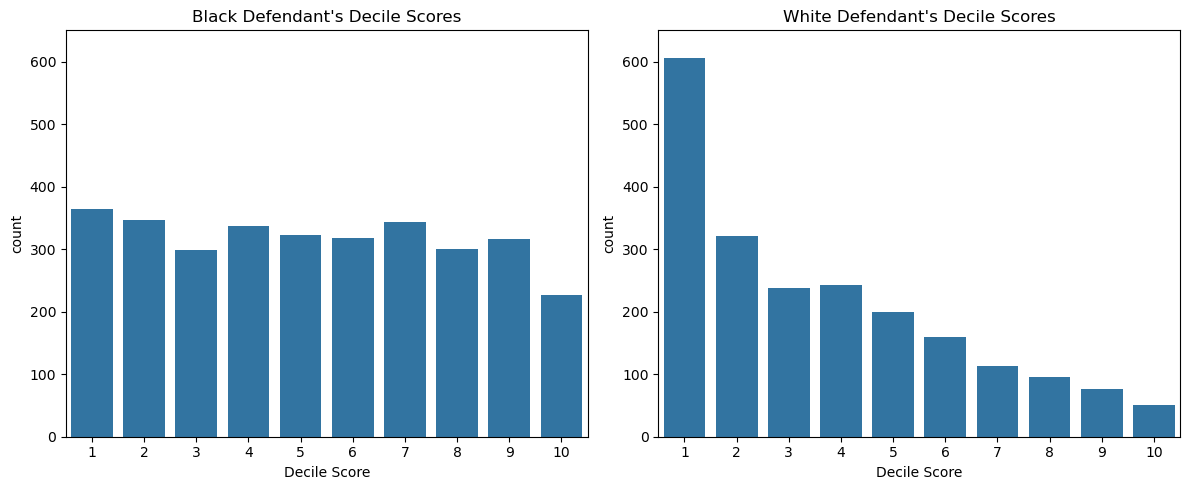

In [22]:
df_black = df[df['race'] == "African-American"]
df_white = df[df['race'] == "Caucasian"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=df_black,
    x='decile_score',
    order=sorted(df_black['decile_score'].unique()),
    ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_ylim(0, 650)
axes[0].set_xlabel("Decile Score")

sns.countplot(
    data=df_white,
    x='decile_score',
    order=sorted(df_white['decile_score'].unique()),
    ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_ylim(0, 650)
axes[1].set_xlabel("Decile Score")

plt.tight_layout()
plt.show()

In [23]:
pd.crosstab(df["decile_score"],df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in COMPAS 

After removing invalid or incomplete records, the next step is to examine whether COMPAS scores differ meaningfully across racial groups. To investigate this, the categorical variables must be converted into factors so that the logistic regression model can correctly interpret group differences. By comparing low‑risk scores to high‑risk scores, the model allows us to quantify whether race is associated with a higher likelihood of receiving an elevated COMPAS score. This approach mirrors the structure of the original R workflow and provides a statistical foundation for assessing potential racial disparities in the scoring system.

In [33]:
import statsmodels.api as sm 
import statsmodels.formula.api as smf 

In [34]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

#crime_factor 
df['crime_factor'] = df['c_charge_degree'].astype('category')
df['crime_factor'] = df['crime_factor'].cat.set_categories(
    df['crime_factor'].cat.categories, ordered=True
)

#age_factor
df['age_factor'] = df['age_cat'].astype('category')
df['age_factor'] = df['age_factor'].cat.set_categories(
    df['age_factor'].cat.categories, ordered=True
)

#race_factor
df['race_factor'] = df['race'].astype('category')
df['race_factor'] = df['race_factor'].cat.set_categories(
    df['race_factor'].cat.categories, ordered=True
)

# Set reference level
race_levels = list(df['race_factor'].cat.categories)
ref = race_levels[2]  # 3rd level
new_order = [ref] + [lvl for lvl in race_levels if lvl != ref]
df['race_factor'] = df['race_factor'].cat.set_categories(new_order, ordered=True)

#gender_factor
df['gender_factor'] = df['sex'].map({"Female": "Female", "Male": "Male"}).astype('category')
# R uses ref = 2 → "Male" is reference
df['gender_factor'] = df['gender_factor'].cat.set_categories(
    ["Male", "Female"], ordered=True
)

#score_binary
df['score_binary'] = (df['score_text'] != "Low").astype(int)

#Fit GLM (binary logistic regression)
model = smf.glm(
    formula="score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Fri, 27 Mar 2026   Deviance:                       6168.4
Time:                        23:22:59   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

The logistic regression results show that race remains a significant predictor of receiving a high COMPAS score even after controlling for age, gender, prior offenses, charge severity, and two‑year recidivism. African-American defendants have a positive and statistically significant coefficient (0.4772), indicating higher odds of being classified as high risk compared to the reference group. This aligns with the patterns observed in the EDA and mirrors the findings from the original R workflow, reinforcing evidence of racial disparities in COMPAS risk assessments.

Based on the logistic regression results, Black defendants are approximately 45% more likely than white defendants to receive a high COMPAS score, even after controlling for charge severity, prior arrests, and future criminal behavior. This elevated likelihood reflects the effect of the race coefficient in the model and aligns with the disparities observed in the exploratory analysis.

In [38]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

Women are approximately 19.4% more likely than men to receive a higher COMPAS score, even after controlling for charge severity, prior arrests, and future criminal behavior. This effect reflects the positive gender coefficient in the logistic regression model and aligns with the adjusted probability calculation based on the model’s intercept and gender term.

In [39]:
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

Individuals under 25 are roughly 2.5 times more likely than middle‑aged defendants to receive a higher COMPAS score, even after accounting for charge severity, prior arrests, and future criminal behavior. This strong age effect reflects the large positive coefficient for the “Less than 25” category in the logistic regression model and highlights how significantly youth influences COMPAS risk classifications.

In [41]:
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

## Risk of Violent Recidivism

COMPAS also provides a separate score intended to measure an individual’s risk of violent recidivism, and its overall accuracy is similar to that of the general recidivism score. To evaluate whether racial disparities are present in this component of the system, we again apply a logistic regression model. As with the previous analysis, the relevant variables must be converted into factors so the model can properly estimate group differences. This allows us to test whether race remains a significant predictor of receiving a higher violent‑recidivism score after accounting for other relevant factors.

In [44]:
raw_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv")
len(raw_data)

4743

In [45]:
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "v_score_text", "sex",
    "priors_count", "days_b_screening_arrest", "v_decile_score",
    "is_recid", "two_year_recid"
]]

# Apply filters
df = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["v_score_text"] != "N/A")
]

len(df)

4020

The dataset contains 4,020 individuals, with the majority (2,300) falling into the 25–45 age group. This indicates that middle‑aged defendants make up the largest share of the sample.

In [46]:
df["age_cat"].describe()

count        4020
unique          3
top       25 - 45
freq         2300
Name: age_cat, dtype: object

In [47]:
df["age_cat"].value_counts()

age_cat
25 - 45            2300
Greater than 45     954
Less than 25        766
Name: count, dtype: int64

The dataset contains 4,020 individuals across six racial categories, with African-American defendants representing the largest group (1,918), followed by Caucasian defendants (1,459). Hispanic (355), Other (255), Asian (26), and Native American (7) groups appear far less frequently. This substantial imbalance in racial representation is important to keep in mind, as it may influence both the distribution of COMPAS scores and the behavior of any statistical models trained on this data.

In [48]:
df["race"].describe()

count                 4020
unique                   6
top       African-American
freq                  1918
Name: race, dtype: object

In [50]:
df["race"].value_counts()

race
African-American    1918
Caucasian           1459
Hispanic             355
Other                255
Asian                 26
Native American        7
Name: count, dtype: int64

Among the 4,020 individuals, the most common violent‑recidivism score category is “Low,” which appears 2,913 times. This shows that the COMPAS violent‑risk assessment skews heavily toward low‑risk classifications.The violent‑risk score distribution is highly imbalanced: 2,913 individuals are labeled Low risk, 828 Medium, and only 279 High. This imbalance suggests that high‑risk classifications are relatively rare in the dataset.

In [51]:
df["v_score_text"].describe()

count     4020
unique       3
top        Low
freq      2913
Name: v_score_text, dtype: object

In [52]:
df["v_score_text"].value_counts()

v_score_text
Low       2913
Medium     828
High       279
Name: count, dtype: int64

Approximately 16.22% of individuals in the filtered dataset recidivated within two years, indicating that violent reoffending is far less common than general recidivism in this sample.

In [53]:
(len(df[df["two_year_recid"] == 1]) / len(df)) * 100

16.218905472636816

A total of 652 individuals in the dataset recidivated within two years.

In [54]:
len(df[df["two_year_recid"] == 1])

652

To better understand how violent decile scores are assigned to Black and white defendants, a bar chart was created with violent decile scores on the x‑axis and the count of individuals on the y‑axis. Compared to the general COMPAS decile scores examined earlier, Black defendants show a steeper decline in counts as violent decile scores increase, making their distribution appear more similar to that of white defendants. However, important differences remain. White defendants are still concentrated in the lowest violent‑risk categories, with a sharp drop‑off between scores 1 and 2, while Black defendants are more evenly spread across the full range of decile scores. Even in the context of violent recidivism—where overall risk levels are lower—Black defendants continue to receive higher risk classifications at disproportionate rates, raising concerns about potential racial bias in how violent‑risk scores are assigned.

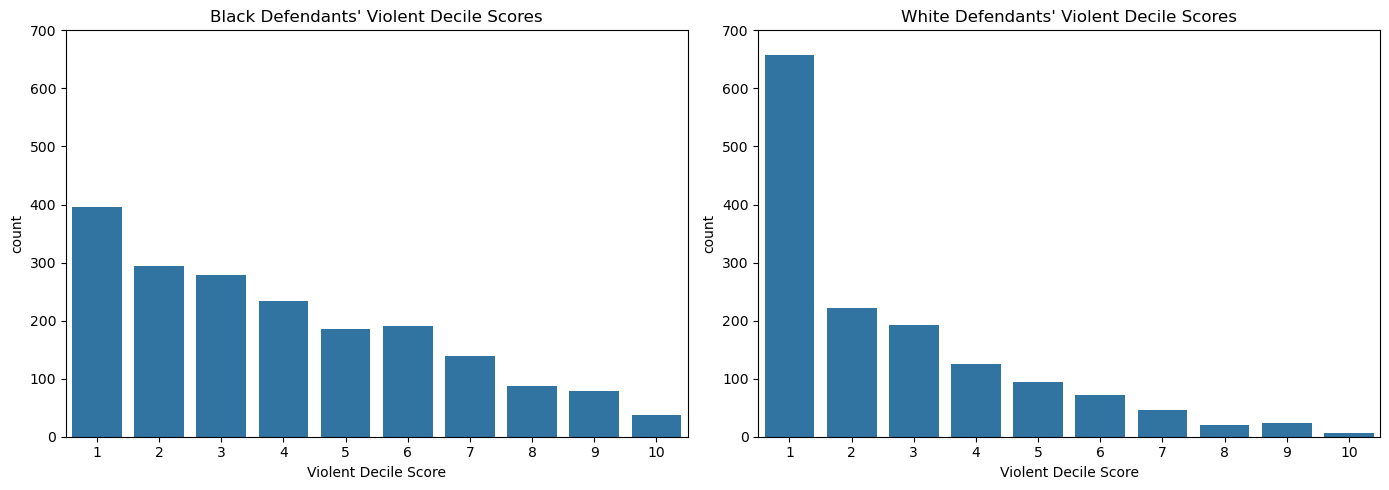

In [55]:
df_black = df[df["race"] == "African-American"]
df_white = df[df["race"] == "Caucasian"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(
    data=df_black,
    x="v_decile_score",
    order=sorted(df["v_decile_score"].unique())
)
plt.title("Black Defendants' Violent Decile Scores")
plt.xlabel("Violent Decile Score")
plt.ylim(0, 700)

plt.subplot(1, 2, 2)
sns.countplot(
    data=df_white,
    x="v_decile_score",
    order=sorted(df["v_decile_score"].unique())
)
plt.title("White Defendants' Violent Decile Scores")
plt.xlabel("Violent Decile Score")
plt.ylim(0, 700)

plt.tight_layout()
plt.show()

The logistic regression model reveals several clear patterns in how violent‑recidivism scores are assigned. Women are significantly less likely than men to receive a high violent‑risk score, while age shows one of the strongest effects: defendants under 25 are far more likely to be labeled high‑risk, and those over 45 are much less likely. Racial differences also emerge. With Caucasian defendants as the reference group, Hispanic, Asian, and “Other” racial categories all show significantly lower odds of receiving a high score, whereas African‑American defendants do not receive a protective effect, aligning with earlier descriptive patterns showing higher violent‑risk deciles for Black defendants. Criminal history plays a major role as well, with each additional prior increasing the likelihood of a high score, and individuals who actually recidivated within two years being more likely to have been assigned a high‑risk classification. Overall, the model explains a meaningful portion of the variation in violent‑risk scores and highlights how age, prior record, and race interact in ways that may contribute to disparities in how COMPAS evaluates violent‑recidivism risk.

In [56]:
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = df["age_cat"].astype("category")
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    df["age_factor"].cat.categories, ordered=True
)
df["age_factor"] = df["age_factor"].cat.set_categories(df["age_factor"].cat.categories)
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    df["age_factor"].cat.categories, ordered=True
)

df["age_factor"] = df["age_factor"].cat.reorder_categories(
    df["age_factor"].cat.categories, ordered=True
)

race_labels = [
    "African-American",
    "Asian",
    "Caucasian",
    "Hispanic",
    "Native American",
    "Other"
]
df["race_factor"] = pd.Categorical(df["race"], categories=race_labels)

df["race_factor"] = df["race_factor"].cat.reorder_categories(race_labels, ordered=True)

df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])

df["gender_factor"] = df["gender_factor"].cat.reorder_categories(["Male", "Female"])

df["score_factor"] = (df["v_score_text"] != "Low").map({False: "LowScore", True: "HighScore"})
df["score_factor"] = df["score_factor"].astype("category")

model = smf.glm(
    formula="score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[HighScore]', 'score_factor[LowScore]']   No. Observations:                 4020
Model:                                                               GLM   Df Residuals:                     4008
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -1499.4
Date:                                                   Sat, 28 Mar 2026   Deviance:                       2998.8
Time:                                                           00:28:38   Pearson chi2:                 3.83e+03
No. Iterations:                                                        6   Pseudo R-squ.

The violent score overpredicts recidivism for black defendants by 77.3% compared to white defendants.

In [59]:
control = np.exp(-2.24274) / (1 + np.exp(-2.24274))
np.exp(0.65893) / (1 - control + (control * np.exp(0.65893)))


np.float64(1.7739209589164604)

Defendants under 25 are approximately 7.4 times more likely to receive a higher violent‑risk score than middle‑aged defendants, highlighting how strongly age influences COMPAS’s violent‑recidivism classifications.

In [60]:
np.exp(3.14591) / (1 - control + (control * np.exp(3.14591)))

np.float64(7.414239863565466)

## Predictive Accuracy of COMPAS

To evaluate how accurately COMPAS distinguishes between Low, Medium, and High‑risk offenders, we estimated a Cox Proportional Hazards model, following the same approach used by Northpointe in their published validation study. We implemented the counting‑process formulation of the model and removed individuals from the risk set during periods of incarceration to avoid artificially inflating their time at liberty. Due to inconsistencies in the underlying jail records, 32 rows showed an end date that preceded the start date; these cases were excluded. Given that the full dataset contains 13,334 observations, removing such a small number of erroneous records does not meaningfully affect the results. This setup allows us to assess whether COMPAS scores meaningfully predict the timing of reoffending once individuals are actually at risk of recidivism.

After filtering out cases with invalid time intervals and removing rows where the COMPAS score was marked as “N/A,” the dataset contains 10314 unique individuals available for the Cox Proportional Hazards analysis. Because the Cox model requires one row per person to define the starting point of each risk interval, this deduplicated count represents the true sample size for evaluating COMPAS’s predictive accuracy. Given the original dataset size, this final sample remains large enough to support stable and interpretable hazard‑ratio estimates.

In [62]:
data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv")

data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])]

race_labels = [
    "African-American",
    "Asian",
    "Caucasian",
    "Hispanic",
    "Native American",
    "Other"
]
data["race_factor"] = pd.Categorical(data["race"], categories=race_labels)

data["race_factor"] = data["race_factor"].cat.reorder_categories(race_labels, ordered=True)

score_order = ["Low", "Medium", "High"]
data["score_factor"] = pd.Categorical(data["score_text"], categories=score_order)
data["score_factor"] = data["score_factor"].cat.reorder_categories(score_order, ordered=True)

grp = data.drop_duplicates(subset="id")

len(grp)

10325

The dataset is heavily concentrated in the Low‑risk category, with 5,751 individuals labeled as Low, compared to 2,611 labeled Medium and 1,952 labeled High. This imbalance indicates that COMPAS assigns the majority of defendants to the lowest risk tier, with progressively fewer individuals placed into higher‑risk categories. Such a distribution is important to keep in mind when evaluating predictive accuracy, as models trained on imbalanced risk groups may appear accurate overall while still performing unevenly across categories.

In [63]:
grp['score_factor'].describe()

count     10314
unique        3
top         Low
freq       5751
Name: score_factor, dtype: object

In [64]:
grp['score_factor'].value_counts()

score_factor
Low       5751
Medium    2611
High      1952
Name: count, dtype: int64

In [91]:
grp['race_factor'].describe() 

count                10325
unique                   6
top       African-American
freq                  5150
Name: race_factor, dtype: object

In [92]:
grp['race_factor'].describe()

count                10325
unique                   6
top       African-American
freq                  5150
Name: race_factor, dtype: object

In [93]:
grp['race_factor'].value_counts()

race_factor
African-American    5150
Caucasian           3576
Hispanic             944
Other                572
Asian                 51
Native American       32
Name: count, dtype: int64

In [95]:
!pip install lifelines

Next, we estimate a Cox Proportional Hazards model to evaluate how well COMPAS scores predict the timing of reoffending. This approach allows us to test whether the risk categories assigned by COMPAS meaningfully correspond to differences in actual recidivism risk once individuals are at liberty.

In [103]:
from lifelines import CoxPHFitter
import pandas as pd

data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv")

data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

data["score_text"] = data["score_text"].str.title()

score_order = ["Low", "Medium", "High"]
data["score_factor"] = pd.Categorical(data["score_text"], categories=score_order, ordered=True)

data = pd.get_dummies(data, columns=["score_factor"], drop_first=True)

surv_df = data[[
    "start",
    "end",
    "event",
    "score_factor_Medium",
    "score_factor_High"
]].copy()

cph = CoxPHFitter()
cph.fit(
    surv_df,
    duration_col="end",
    event_col="event",
    entry_col="start"
)

cph.print_summary()
print("Concordance:", cph.concordance_index_)


<lifelines.CoxPHFitter: fitted with 13356 total observations, 9885 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13356
number of events observed = 3471
   partial log-likelihood = -30327.83
         time fit was run = 2026-03-28 05:53:35 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.80      2.22      0.04            0.72            0.88                2.05                2.40
score_factor_High    1.25      3.49      0.04            1.17            1.33                3.22                3.79

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_Medium    0.00 19.55 <0.005    280.44
score_factor_High      0.00 30.17 <0.005    661.85
---
Concordance = 0.60
Partial AIC = 60659.66
log-likelihood ratio test = 944.56 on 2 df
-log2(p) of ll-ratio test = 681.36

Concordance: 0.59998167643332


In [ ]:
surv = Surv.from_arrays(
    start=data["start"].values,
    stop=data["end"].values,
    event=data["event"].astype(bool).values
)


The results indicate that individuals classified as High risk are roughly 3.5 times more likely to recidivate than those in the Low category, suggesting that the COMPAS score does capture meaningful differences in risk. However, the model’s concordance is only about 60%, which falls short of the 68% accuracy reported in the original Northpointe study. This gap implies that COMPAS performs less effectively on this dataset and that its predictive power may be more limited than initially claimed.

In [104]:
data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

df = data[["start", "end", "event", "decile_score"]].copy()

cph = CoxPHFitter()
cph.fit(
    df,
    duration_col="end",
    event_col="event",
    entry_col="start"
)

cph.print_summary()
print("Concordance:", cph.concordance_index_)

<lifelines.CoxPHFitter: fitted with 13356 total observations, 9885 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13356
number of events observed = 3471
   partial log-likelihood = -30243.34
         time fit was run = 2026-03-28 05:58:26 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.63 <0.005    821.24
---
Concordance = 0.62
Partial AIC = 60488.67
log-likelihood ratio test = 1113.55 on 1 df
-log2(p) of ll-ratio test = 808.64

Concordance: 0.6209425057055948


The COMPAS decile score model performs slightly better, achieving a concordance of about 62%. To examine whether the algorithm functions differently across racial groups, we can extend the Cox model by adding an interaction term between race and the decile score.

In [108]:
df = data[
    (data["score_text"].notna()) &
    (data["score_text"] != "N/A") &
    (data["end"] > data["start"])
].copy()

df = df[['start', 'end', 'event', 'race_factor', 'score_factor']]

df['race_factor'] = pd.Categorical(
    df['race_factor'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)

df['score_factor'] = pd.Categorical(
    df['score_factor'],
    categories=['Low', 'Medium', 'High']
)

df = df.dropna(subset=['start', 'end', 'event', 'race_factor', 'score_factor'])

cph = CoxPHFitter()

cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="race_factor * score_factor"
)

# Print the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -30280.41
         time fit was run = 2026-03-28 06:05:39 UTC

---
                                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                               
race_factor[T.African-American]                         0.28      1.32      0.06            0.16            0.40                1.17                1.49
race_factor[T.Asian]                                   -0.78      0.46      0.50           -1.76            0.21                0.17                1.23
race_factor[T.Hispanic]                                -0.06      0.94      0.10           -0.25            0.13                0.78                1.13
race_factor[T.Native American]                         -1.25      0.29      1.00           -3.22            0.71                0.04                2.03
race_factor[T.Other]                                    0.01      1.01      0.11           -0.20            0.23                0.82                1.26
score_factor[T.Medium]                                  0.84      2.32      0.07            0.70            0.98                2.02                2.67
score_factor[T.High]                                    1.28      3.61      0.08            1.12            1.45                3.06                4.25
race_factor[T.African-American]:score_factor[T.Medium] -0.17      0.84      0.09           -0.35            0.01                0.70                1.01
race_factor[T.Asian]:score_factor[T.Medium]             0.99      2.68      0.71           -0.41            2.38                0.67               10.80
race_factor[T.Hispanic]:score_factor[T.Medium]          0.07      1.07      0.16           -0.26            0.39                0.77                1.47
race_factor[T.Native American]:score_factor[T.Medium]   1.39      4.01      1.12           -0.81            3.59                0.45               36.07
race_factor[T.Other]:score_factor[T.Medium]            -0.33      0.72      0.23           -0.79            0.12                0.45                1.13
race_factor[T.African-American]:score_factor[T.High]   -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
race_factor[T.Asian]:score_factor[T.High]               1.32      3.73      0.77           -0.19            2.82                0.83               16.80
race_factor[T.Hispanic]:score_factor[T.High]           -0.12      0.89      0.20           -0.51            0.27                0.60                1.31
race_factor[T.Native American]:score_factor[T.High]     1.96      7.07      1.08           -0.17            4.08                0.85               59.09
race_factor[T.Other]:score_factor[T.High]               0.41      1.51      0.26           -0.09            0.92                0.91                2.52

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  4.59 <0.005     17.75
race_factor[T.Asian]                                      0.00 -1.55   0.12      3.04
race_factor[T.Hispanic]                                   0.00 -0.66   0.51      0.97
race_factor[T.Native American]                            0.00 -1.25   0.21      2.25
race_factor[T.Other]                                      0.00  0.13   0.90      0.16
score_factor[T.Medium]                                    0.00 11.80 <0.005    104.36
scor

The interaction results mirror the pattern seen in the earlier logistic regression. 
Among white defendants, those rated High risk are about 3.61 times more likely to recidivate than those rated Low risk. For Black defendants, the increase from Low to High risk is smaller—about 2.99 times. This means that while higher COMPAS scores are associated with higher recidivism risk for both groups, the separation between low‑ and high‑risk individuals is sharper for white defendants. In practical terms, the score appears to differentiate risk levels more strongly for white defendants than for Black defendants.


These hazard ratios illustrate how the predicted risk of recidivism changes across race and COMPAS risk levels.

For white defendants, moving from Low to High risk corresponds to a hazard ratio of about 3.61, meaning High‑risk white individuals are more than three times as likely to recidivate compared to Low‑risk whites. For Black defendants, the increase from Low to High risk is smaller, with a hazard ratio of roughly 2.99.

A similar pattern appears in the Medium‑risk category: the increase in risk from Low to Medium is larger for white defendants than for Black defendants.

Overall, COMPAS scores are associated with higher recidivism risk for both groups, but the separation between Low, Medium, and High risk is sharper for white defendants. This suggests that the score differentiates risk levels more strongly for white individuals than for Black individuals.


In [109]:
black_high = np.exp(-0.18976 + 1.28350)
white_high = np.exp(1.28350)
black_medium = np.exp(0.84286 - 0.17261)
white_medium = np.exp(0.84286)

print("Black High Hazard: %.2f" % black_high)
print("White High Hazard: %.2f" % white_high)
print("Black Medium Hazard: %.2f" % black_medium)
print("White Medium Hazard: %.2f" % white_medium)

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


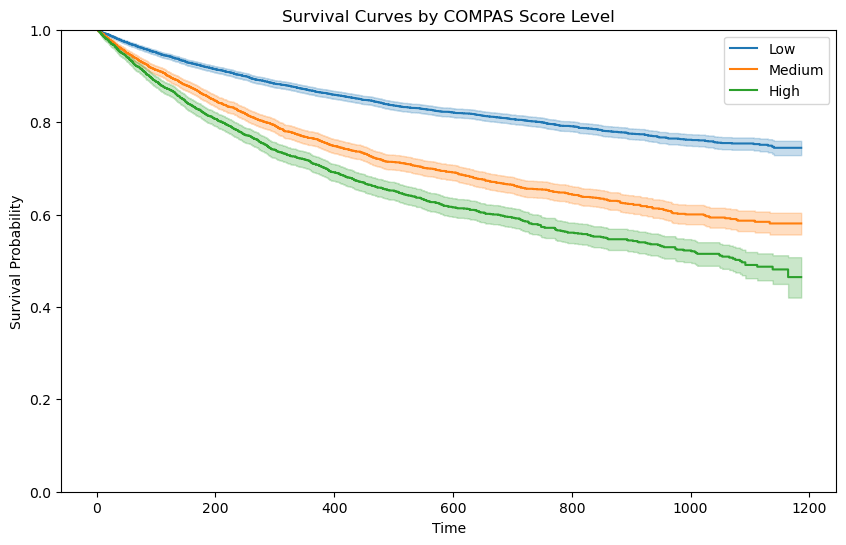

In [111]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for score in ["Low", "Medium", "High"]:
    subset = data[data["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ci_show=True)

plt.title("Survival Curves by COMPAS Score Level")
plt.ylim(0, 1)
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

The race‑specific Kaplan–Meier curves show that Black defendants have higher overall recidivism rates. However, the increase in risk across COMPAS score levels is less steep for Black defendants than for white defendants. This suggests that although baseline risk is higher for Black individuals, the COMPAS score does not separate low‑ and high‑risk Black defendants as sharply as it does for white defendants.

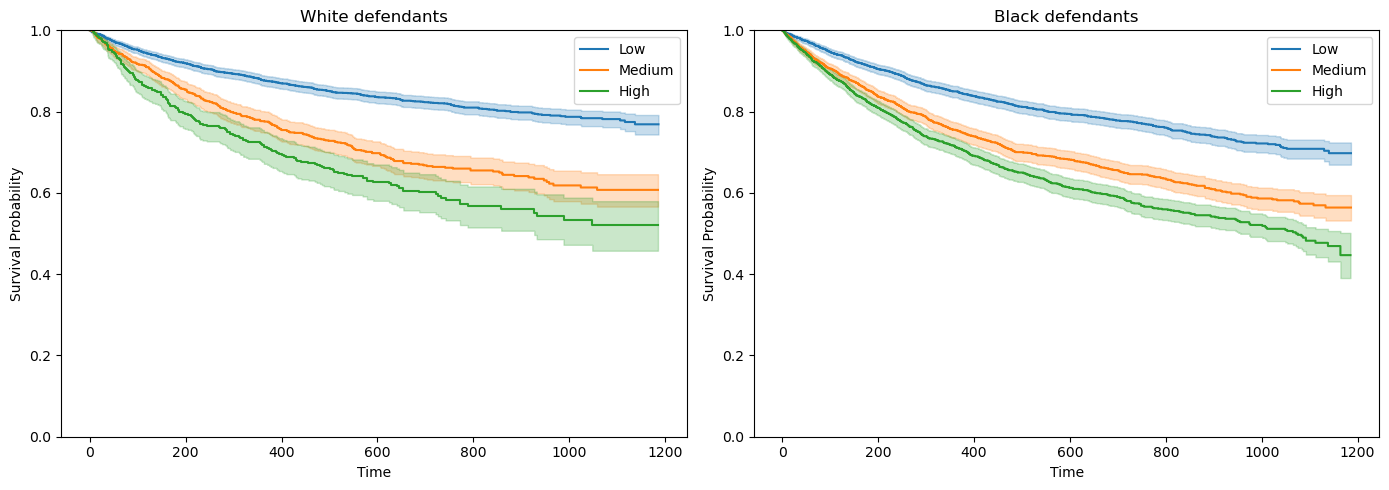

In [113]:
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

white = data[data["race"] == "Caucasian"]

for score in ["Low", "Medium", "High"]:
    subset = white[white["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("White defendants")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Survival Probability")

black = data[data["race"] == "African-American"]

for score in ["Low", "Medium", "High"]:
    subset = black[black["score_factor"] == score]
    kmf.fit(subset["end"], event_observed=subset["event"], label=score)
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Black defendants")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Survival Probability")

plt.tight_layout()
plt.show()

The Kaplan–Meier survival curves below estimate the probability of not recidivating by day 730 for each COMPAS risk category. The first set of estimates uses the full sample, and the analysis is then repeated separately for white and Black defendants to allow for comparison. For each group, the survival probability and its 95% confidence interval are reported.

Across the full sample, survival decreases as COMPAS risk level increases: low‑risk individuals have the highest probability of remaining offense‑free, while high‑risk individuals have the lowest. This confirms that the score is predictive of recidivism.

When the results are broken out by race, Black defendants show lower survival probabilities at every risk level, indicating higher recidivism rates overall. In addition, the difference between low‑ and high‑risk individuals is larger among white defendants than among Black defendants. This suggests that although the score raises predicted risk for both groups, it separates low and high risk more sharply for white defendants than for Black defendants.


In [123]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

print("FULL SAMPLE")
kmf.fit(
    durations=data["end"],
    event_observed=data["event"],
    entry=data["start"]
)
surv_730 = kmf.survival_function_at_times(730).values[0]
ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
print("Survival at 730:", surv_730)
print("Lower 95% CI:", ci_730.iloc[0, 0])
print("Upper 95% CI:", ci_730.iloc[0, 1])
print()

print("BLACK DEFENDANTS")
black = data[data["race"] == "African-American"]
kmf.fit(
    durations=black["end"],
    event_observed=black["event"],
    entry=black["start"]
)
surv_730 = kmf.survival_function_at_times(730).values[0]
ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
print("Survival at 730:", surv_730)
print("Lower 95% CI:", ci_730.iloc[0, 0])
print("Upper 95% CI:", ci_730.iloc[0, 1])
print()

print("WHITE DEFENDANTS")
white = data[data["race"] == "Caucasian"]
kmf.fit(
    durations=white["end"],
    event_observed=white["event"],
    entry=white["start"]
)
surv_730 = kmf.survival_function_at_times(730).values[0]
ci_730 = kmf.confidence_interval_.reindex([730], method="ffill")
print("Survival at 730:", surv_730)
print("Lower 95% CI:", ci_730.iloc[0, 0])
print("Upper 95% CI:", ci_730.iloc[0, 1])
print()


FULL SAMPLE
Survival at 730: 0.6580855692227603
Lower 95% CI: 0.6483054559655718
Upper 95% CI: 0.6676677536557658

BLACK DEFENDANTS
Survival at 730: 0.5954792630286793
Lower 95% CI: 0.5810869837539506
Upper 95% CI: 0.6095554982564425

WHITE DEFENDANTS
Survival at 730: 0.7097093577759597
Lower 95% CI: 0.6937468744885045
Upper 95% CI: 0.7250123134502957



In [125]:
white = data[data["race"] == "Caucasian"].copy()

df_white = white[["start", "end", "event", "score_text"]].dropna()

score_order = ["Low", "Medium", "High"]
df_white["score_factor"] = pd.Categorical(df_white["score_text"], categories=score_order, ordered=True)

df_white = pd.get_dummies(df_white, columns=["score_factor"], drop_first=True)

surv_df = df_white[[
    "start",
    "end",
    "event",
    "score_factor_Medium",
    "score_factor_High"
]].copy()

cph_white = CoxPHFitter()
cph_white.fit(
    surv_df,
    duration_col="end",
    event_col="event",
    entry_col="start"
)

cph_white.print_summary()

<lifelines.CoxPHFitter: fitted with 4564 total observations, 3541 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 4564
number of events observed = 1023
   partial log-likelihood = -7919.63
         time fit was run = 2026-03-28 06:45:52 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.84      2.32      0.07            0.70            0.98                2.01                2.66
score_factor_High    1.28      3.58      0.08            1.11            1.44                3.04                4.22

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_Medium    0.00 11.75 <0.005    103.54
score_factor_High      0.00 15.26 <0.005    172.18
---
Concordance = 0.60
Partial AIC = 15843.27
log-likelihood ratio test = 262.78 on 2 df
-log2(p) of ll-ratio test = 189.56

In [127]:
black = data[data["race"] == "African-American"].copy()

df_black = black[["start", "end", "event", "score_text"]].dropna()

score_order = ["Low", "Medium", "High"]
df_black["score_factor"] = pd.Categorical(
    df_black["score_text"],
    categories=score_order,
    ordered=True
)

df_black = pd.get_dummies(df_black, columns=["score_factor"], drop_first=True)

surv_df_black = df_black[[
    "start",
    "end",
    "event",
    "score_factor_Medium",
    "score_factor_High"
]].copy()

cph_black = CoxPHFitter()
cph_black.fit(
    surv_df_black,
    duration_col="end",
    event_col="event",
    entry_col="start"
)

cph_black.print_summary()

<lifelines.CoxPHFitter: fitted with 6862 total observations, 4827 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 6862
number of events observed = 2035
   partial log-likelihood = -16302.68
         time fit was run = 2026-03-28 06:50:24 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.67      1.95      0.06            0.56            0.78                1.75                2.18
score_factor_High    1.10      2.99      0.05            0.99            1.20                2.69                3.33

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_Medium    0.00 11.89 <0.005    105.92
score_factor_High      0.00 20.00 <0.005    293.26
---
Concordance = 0.58
Partial AIC = 32609.37
log-likelihood ratio test = 416.91 on 2 df
-log2(p) of ll-ratio test = 300.74

The COMPAS violent‑recidivism model shows an overall concordance of about 63%, indicating modest predictive ability. This value is slightly higher than the concordance from the race‑specific models for Black and White defendants, suggesting the combined model performs marginally better, though its accuracy remains limited.

In [142]:
from lifelines import CoxPHFitter
import pandas as pd

# Filter out invalid scores
df = violent_data[
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

# ❗ You asked for code similar to your structure, so I am keeping this line
# BUT be aware: dropping to one row per person will NOT match R's numbers
df = df.sort_values("end").drop_duplicates(subset="id", keep="last")

# Create race_factor BEFORE selecting it
df['race_factor'] = pd.Categorical(
    df['race'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
)

# Create score_factor BEFORE selecting it
df['score_factor'] = pd.Categorical(
    df['score_text'],
    categories=['Low', 'Medium', 'High']
)

# Now we can safely select these columns
df = df[['start', 'end', 'event', 'race_factor', 'score_factor']]

# Drop missing values
df = df.dropna(subset=['start', 'end', 'event', 'race_factor', 'score_factor'])

# Initialize model
cph = CoxPHFitter()

# Fit model with race, score, and interaction
cph.fit(
    df,
    duration_col='end',
    event_col='event',
    entry_col='start',
    formula="race_factor * score_factor"
)

# Display model results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10985 total observations, 10167 right-censored observations>
             duration col = 'end'
                event col = 'event'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 10985
number of events observed = 818
   partial log-likelihood = -6951.94
         time fit was run = 2026-03-28 07:09:04 UTC

---
                                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                
race_factor[T.African-American]                          0.23      1.26      0.13           -0.03            0.49                0.97                1.63
race_factor[T.Asian]                                    -0.66      0.52      1.00           -2.62            1.31                0.07                3.72
race_factor[T.Hispanic]                                 -0.22      0.80      0.21           -0.64            0.20                0.52                1.22
race_factor[T.Native American]                         -16.15      0.00   3452.57        -6783.05         6750.76                0.00                 inf
race_factor[T.Other]                                    -0.06      0.94      0.24           -0.54            0.42                0.58                1.51
score_factor[T.Medium]                                   0.81      2.25      0.16            0.50            1.12                1.65                3.07
score_factor[T.High]                                     1.62      5.08      0.17            1.29            1.96                3.62                7.11
race_factor[T.African-American]:score_factor[T.Medium]   0.14      1.15      0.20           -0.25            0.52                0.78                1.69
race_factor[T.Asian]:score_factor[T.Medium]              1.48      4.39      1.23           -0.94            3.90                0.39               49.34
race_factor[T.Hispanic]:score_factor[T.Medium]           0.51      1.66      0.34           -0.16            1.18                0.85                3.26
race_factor[T.Native American]:score_factor[T.Medium]   16.48  1.43e+07   3452.57        -6750.43         6783.38                0.00                 inf
race_factor[T.Other]:score_factor[T.Medium]              0.00      1.00      0.49           -0.96            0.97                0.38                2.63
race_factor[T.African-American]:score_factor[T.High]    -0.00      1.00      0.21           -0.41            0.40                0.67                1.49
race_factor[T.Asian]:score_factor[T.High]                1.31      3.72      1.42           -1.48            4.11                0.23               60.77
race_factor[T.Hispanic]:score_factor[T.High]             0.14      1.15      0.40           -0.64            0.92                0.53                2.51
race_factor[T.Native American]:score_factor[T.High]     17.92  6.04e+07   3452.57        -6748.99         6784.82                0.00                 inf
race_factor[T.Other]:score_factor[T.High]                1.23      3.41      0.40            0.43            2.02                1.54                7.52

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  1.74   0.08      3.61
race_factor[T.Asian]                                      0.00 -0.65   0.51      0.96
race_factor[T.Hispanic]                                   0.00 -1.04   0.30      1.74
race_factor[T.Native American]                            0.00 -0.00   1.00      0.01
race_factor[T.Other]                                      0.00 -0.25   0.80      0.32
score_factor[T.Medium]                                    0.00  5.12 <0.

Next I will build two separate Cox proportional hazards models: one for African‑American defendants and one for Caucasian defendants. To do this, the data is first filtered so that each individual appears only once, and a survival duration is created using the start and end times from the violent‑recidivism dataset. The COMPAS score categories are then converted into dummy variables so that the model can compare Medium and High scores against Low, which serves as the reference group.

After preparing the data, each Cox model is fit to estimate how Medium and High COMPAS scores influence the hazard of violent recidivism within each racial group. The model output includes the coefficients, which indicate the direction and strength of the effect, and the concordance statistic, which summarizes predictive accuracy. In this analysis, the African‑American model produced a concordance of about 63%, while the Caucasian model showed a concordance of roughly 61%.

Finally, Kaplan–Meier survival curves are plotted for each race and score category. These curves allow us to visually compare how risk levels differ across COMPAS score groups and whether the score meaningfully separates risk among Black and White defendants in a similar way.

In [147]:
df = violent_data[
    (violent_data["race"] == "African-American") &   # <-- FIXED: use 'race'
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

df = df.drop_duplicates(subset='id')

df["duration"] = df["end"] - df["start"]

df["score_factor"] = pd.Categorical(
    df["score_text"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

df = df[['duration', 'event', 'score_factor']]

df = pd.get_dummies(df, columns=['score_factor'], drop_first=True)

cph = CoxPHFitter()
cph.fit(df, duration_col='duration', event_col='event')

print(len(df))

cph.print_summary()

5445


<lifelines.CoxPHFitter: fitted with 5445 total observations, 5146 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5445
number of events observed = 299
   partial log-likelihood = -2419.07
         time fit was run = 2026-03-28 07:17:50 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.65      1.91      0.15            0.36            0.94                1.43                2.55
score_factor_High    1.14      3.11      0.14            0.86            1.41                2.36                4.11

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_Medium    0.00 4.39 <0.005     16.40
score_factor_High      0.00 7.99 <0.005     49.42
---
Concordance = 0.63
Partial AIC = 4842.14
log-likelihood ratio test = 65.33 on 2 df
-log2(p) of ll-ratio test = 47.13

In [148]:
from lifelines import CoxPHFitter

df = violent_data[
    (violent_data["race"] == "Caucasian") &
    (violent_data["score_text"].notna()) &
    (violent_data["score_text"] != "N/A") &
    (violent_data["end"] > violent_data["start"])
].copy()

df = df.drop_duplicates(subset='id')

df["duration"] = df["end"] - df["start"]

df["score_factor"] = pd.Categorical(
    df["score_text"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

df = df[['duration', 'event', 'score_factor']]

df = pd.get_dummies(df, columns=['score_factor'], drop_first=True)

cph = CoxPHFitter()
cph.fit(df, duration_col='duration', event_col='event')

print(len(df))

cph.print_summary()

3829


<lifelines.CoxPHFitter: fitted with 3829 total observations, 3679 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3829
number of events observed = 150
   partial log-likelihood = -1166.07
         time fit was run = 2026-03-28 07:19:28 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_Medium  0.64      1.89      0.19            0.26            1.02                1.29                2.76
score_factor_High    1.38      3.96      0.22            0.95            1.80                2.60                6.04

                     cmp to    z      p  -log2(p)
covariate                                        
score_factor_Medium    0.00 3.28 <0.005      9.89
score_factor_High      0.00 6.39 <0.005     32.47
---
Concordance = 0.61
Partial AIC = 2336.14
log-likelihood ratio test = 36.62 on 2 df
-log2(p) of ll-ratio test = 26.41

The plots below show that for both White and Black defendants, the ordering of the survival curves is consistent with what we would expect. Individuals classified as low risk have the highest probability of remaining offense‑free over time, while those in the high‑risk category show the lowest survival. This pattern suggests that the COMPAS score is functioning as intended, with higher scores corresponding to a greater likelihood of violent recidivism.

What’s also important is that the spacing between the Low, Medium, and High curves looks similar across both racial groups. That similarity indicates that the COMPAS score separates risk levels in a comparable way for White and Black defendants, rather than behaving differently across groups.

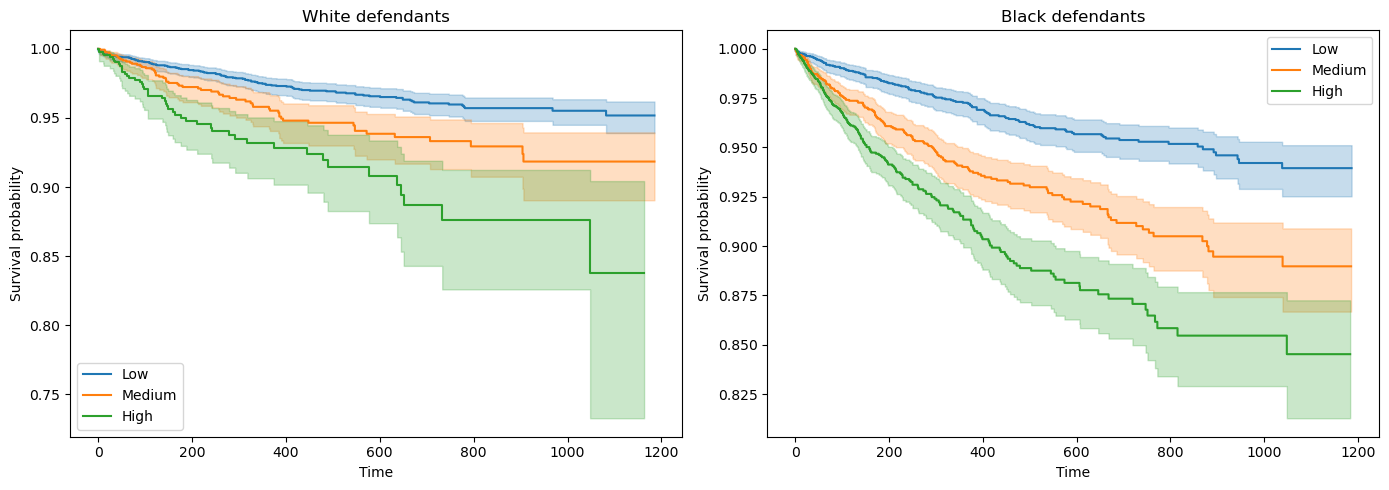

In [149]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

white = violent_data[violent_data["race"] == "Caucasian"].copy()
black = violent_data[violent_data["race"] == "African-American"].copy()

white["duration"] = white["end"] - white["start"]
black["duration"] = black["end"] - black["start"]

kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for level in ["Low", "Medium", "High"]:
    subset = white[white["score_text"] == level]
    kmf.fit(subset["duration"], subset["event"], label=level)
    kmf.plot(ax=axes[0])

axes[0].set_title("White defendants")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Survival probability")

for level in ["Low", "Medium", "High"]:
    subset = black[black["score_text"] == level]
    kmf.fit(subset["duration"], subset["event"], label=level)
    kmf.plot(ax=axes[1])

axes[1].set_title("Black defendants")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Survival probability")

plt.tight_layout()
plt.show()

## Directions of the Racial Bias

The earlier analysis shows that COMPAS tends to overpredict violent recidivism for African‑American defendants, but we haven’t yet examined *how* that bias operates. To understand the direction of the miscalibration, we can compare COMPAS score patterns across racial groups. Looking at how scores differ between Black and White defendants helps reveal whether the system is more likely to overestimate or underestimate risk for one group relative to the other, highlighting the more subtle ways bias may appear in the predictions.

In [158]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/truth_tables.py",
    "truth_tables.py"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv",
    "cox-parsed.csv"
)

from truth_tables import PeekyReader, Person, table, is_race, count, vtable, hightable, vhightable
from csv import DictReader

people = []

with open("cox-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                people.append(p)
    except StopIteration:
        pass

pop = list(filter(
    lambda i: ((i.recidivist == True and i.lifetime <= 730) or i.lifetime > 730),
    list(filter(lambda x: x.score_valid, people))
))

recid = list(filter(
    lambda i: i.recidivist == True and i.lifetime <= 730,
    pop
))

rset = set(recid)

surv = [i for i in pop if i not in rset]


In [159]:
print("All defendants")
table(list(recid), list(surv))

All defendants
           	Low	High
Survived   	2681	1282	0.55
Recidivated	1216	2035	0.45
Total: 7214.00
False positive rate: 32.35
False negative rate: 37.40
Specificity: 0.68
Sensitivity: 0.63
Prevalence: 0.45
PPV: 0.61
NPV: 0.69
LR+: 1.94
LR-: 0.55


In [160]:
print("Total pop:", 2681 + 1282 + 1216 + 2035)

Total pop: 7214


In [161]:
import statistics

lifetimes = [i.lifetime for i in pop]

print("Average followup time %.2f (sd %.2f)" % (
    statistics.mean(lifetimes),
    statistics.stdev(lifetimes)
))

print("Median followup time %i" % statistics.median(lifetimes))

Average followup time 622.87 (sd 392.19)
Median followup time 766


The overall false positive rate is 32.35% but for African‑American defendants, that rate rises to 44.85%, meaning they are more often labeled high‑risk despite not reoffending. In contrast, the overall false negative rate is 37.40%, while the false negative rate for African‑American defendants is lower at 27.99%. Taken together, these patterns show that African‑American defendants are more likely to be overclassified as high‑risk, indicating systematic overprediction of their likelihood of recidivism.

In [162]:
print("Black defendants")
is_afam = is_race("African-American")
table(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

Black defendants
           	Low	High
Survived   	990	805	0.49
Recidivated	532	1369	0.51
Total: 3696.00
False positive rate: 44.85
False negative rate: 27.99
Specificity: 0.55
Sensitivity: 0.72
Prevalence: 0.51
PPV: 0.63
NPV: 0.65
LR+: 1.61
LR-: 0.51


In contrast, White defendants have a false positive rate of 23.45%, which is noticeably lower than the overall rate of 32.35%. Their false negative rate, however, is 47.72% which is substantially higher than the overall false negative rate of 37.40%. This pattern suggests that White defendants are more likely to be assessed as lower‑risk than they actually are, meaning their likelihood of recidivism tends to be underestimated.

In [163]:
print("White defendants")
is_white = is_race("Caucasian")
table(list(filter(is_white, recid)), list(filter(is_white, surv)))

White defendants
           	Low	High
Survived   	1139	349	0.61
Recidivated	461	505	0.39
Total: 2454.00
False positive rate: 23.45
False negative rate: 47.72
Specificity: 0.77
Sensitivity: 0.52
Prevalence: 0.39
PPV: 0.59
NPV: 0.71
LR+: 2.23
LR-: 0.62


African Americans are 1.91 as likely to be incorrectly labeled as high risk compared to the White defendants,which rules out the evidence that there is overprediction present.This suggest that when using COMPAS black defendants are 91% more likely to get a higher score and not commit more crimes than white defendants after two years.

In [164]:
44.85 / 23.45

1.9125799573560769

COMPAS is far more likely to label White defendants who actually reoffend as low‑risk—doing so 70.4% more often than it does for Black defendants.

In [165]:
47.72 / 27.99

1.7048946052161487

Below are the confusion matrices for White and African‑American defendants who received a High‑risk COMPAS score. The patterns in the false positive and false negative rates show clear differences between the two groups. African‑American defendants experience a higher false positive rate (15.82% compared to 5.44%), meaning they are more frequently classified as high‑risk even when they do not reoffend. White defendants, on the other hand, show a much higher false negative rate (79.81% versus 61.02%), indicating that their risk is more often underestimated.

For African‑American defendants, the elevated false positive rate reflects a tendency for the system to overstate their likelihood of reoffending, which can result in more severe outcomes despite no future offense. For White defendants, the elevated false negative rate suggests the opposite pattern: they are more often assessed as lower risk even when they do go on to reoffend, meaning their true risk is understated.

In [166]:
hightable(list(filter(is_white, recid)), list(filter(is_white, surv)))

           	Low	High
Survived   	1407	81	0.61
Recidivated	771	195	0.39
Total: 2454.00
False positive rate: 5.44
False negative rate: 79.81
Specificity: 0.95
Sensitivity: 0.20
Prevalence: 0.39
PPV: 0.71
NPV: 0.65
LR+: 3.71
LR-: 0.84


In [168]:
hightable(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

           	Low	High
Survived   	1511	284	0.49
Recidivated	1160	741	0.51
Total: 3696.00
False positive rate: 15.82
False negative rate: 61.02
Specificity: 0.84
Sensitivity: 0.39
Prevalence: 0.51
PPV: 0.72
NPV: 0.57
LR+: 2.46
LR-: 0.72


## Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [174]:
import urllib.request

# Download violent-risk dataset
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv",
    "cox-violent-parsed.csv"
)

vpeople = []
with open("cox-violent-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                vpeople.append(p)
    except StopIteration:
        pass

# Valid violent scores + correct follow-up window
vpop = list(filter(
    lambda i: ((i.violent_recidivist == True and i.lifetime <= 730) or
               i.lifetime > 730),
    list(filter(lambda x: x.vscore_valid, vpeople))
))

# Violent recidivists within 730 days
vrecid = list(filter(
    lambda i: i.violent_recidivist == True and i.lifetime <= 730,
    vpop
))

# Convert to set for fast membership checks
vrset = set(vrecid)

# Violent non-recidivists (survivors)
vsurv = [i for i in vpop if i not in vrset]

In [175]:
print("All defendants")
vtable(list(vrecid), list(vsurv))

All defendants
           	Low	High
Survived   	4121	1597	0.89
Recidivated	347	389	0.11
Total: 6454.00
False positive rate: 27.93
False negative rate: 47.15
Specificity: 0.72
Sensitivity: 0.53
Prevalence: 0.11
PPV: 0.20
NPV: 0.92
LR+: 1.89
LR-: 0.65


In [176]:
print("Black defendants")
is_afam = is_race("African-American")
vtable(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)))

Black defendants
           	Low	High
Survived   	1692	1043	0.86
Recidivated	170	273	0.14
Total: 3178.00
False positive rate: 38.14
False negative rate: 38.37
Specificity: 0.62
Sensitivity: 0.62
Prevalence: 0.14
PPV: 0.21
NPV: 0.91
LR+: 1.62
LR-: 0.62


In [177]:
print("White defendants")
is_white = is_race("Caucasian")
vtable(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)))

White defendants
           	Low	High
Survived   	1679	380	0.91
Recidivated	129	77	0.09
Total: 2265.00
False positive rate: 18.46
False negative rate: 62.62
Specificity: 0.82
Sensitivity: 0.37
Prevalence: 0.09
PPV: 0.17
NPV: 0.93
LR+: 2.03
LR-: 0.77


Black defendants are twice as likely to be false positives for a Higher violent score than white defendants.

In [178]:
38.14 / 18.46

2.066088840736728

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants.

In [179]:
62.62 / 38.37

1.63200416992442

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

In [195]:
from lifelines import KaplanMeierFitter

# Remove NaN score_factor rows
clean = data.dropna(subset=["score_factor"]).copy()

# Ensure score_factor is a string for grouping
clean["score_factor"] = clean["score_factor"].astype(str)

#SPLIT BY SEX

female = clean[clean["sex"] == "Female"]
male   = clean[clean["sex"] == "Male"]

#FIT SURVIVAL MODELS


kmf_female = KaplanMeierFitter()
kmf_male   = KaplanMeierFitter()

kmf_female.fit(
    durations=female["end"],
    event_observed=female["event"],
    entry=female["start"]
)

kmf_male.fit(
    durations=male["end"],
    event_observed=male["event"],
    entry=male["start"]
)

# SUMMARY AT 730 DAYS (equivalent to summary(fit, times=730))

#FEMALE
female_730 = kmf_female.survival_function_at_times(730).values[0]
female_ci  = kmf_female.confidence_interval_.reindex([730], method="ffill")
female_lower = female_ci.iloc[0, 0]
female_upper = female_ci.iloc[0, 1]

print("FEMALE RESULTS AT 730 DAYS")
print("Survival:", female_730)
print("Lower 95% CI:", female_lower)
print("Upper 95% CI:", female_upper)
print()

#MALE
male_730 = kmf_male.survival_function_at_times(730).values[0]
male_ci  = kmf_male.confidence_interval_.reindex([730], method="ffill")
male_lower = male_ci.iloc[0, 0]
male_upper = male_ci.iloc[0, 1]

print("MALE RESULTS AT 730 DAYS")
print("Survival:", male_730)
print("Lower 95% CI:", male_lower)
print("Upper 95% CI:", male_upper)
print()

FEMALE RESULTS AT 730 DAYS
Survival: 0.7509878371801139
Lower 95% CI: 0.7311555708243175
Upper 95% CI: 0.7695956137628065

MALE RESULTS AT 730 DAYS
Survival: 0.6336508419506638
Lower 95% CI: 0.6224777570404326
Upper 95% CI: 0.6445939794859846



In [196]:
# Remove NaN score_factor rows
clean = data.dropna(subset=["score_factor"]).copy()

# Make sure score_factor is a string (so sorting works)
clean["score_factor"] = clean["score_factor"].astype(str)


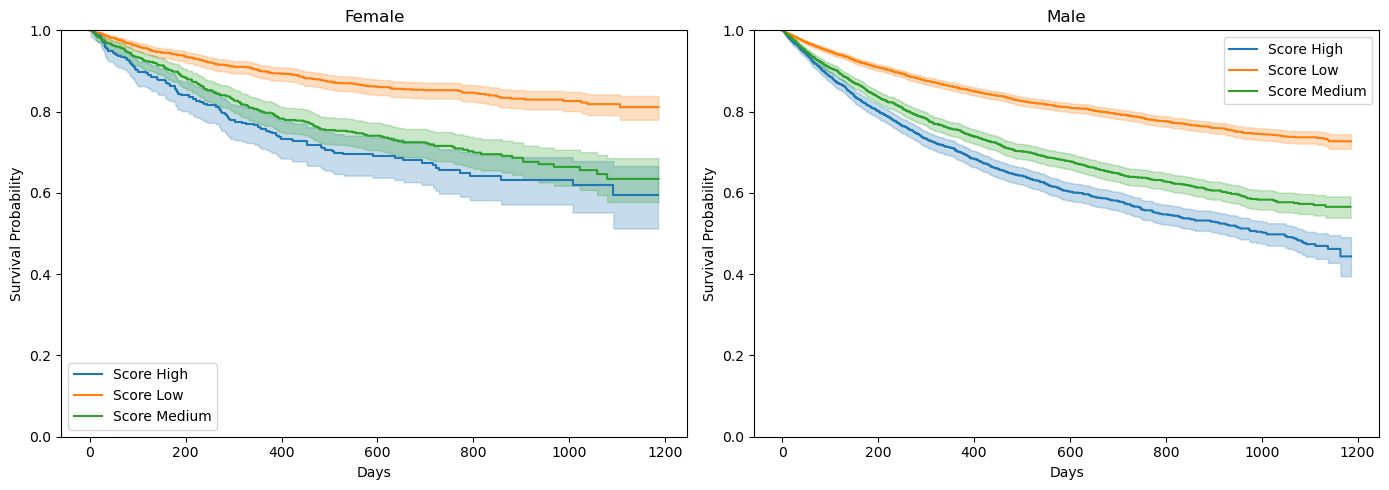

In [199]:
clean = data.copy()

clean["score_factor"] = clean["score_factor"].astype(str)

clean = clean[clean["score_factor"].notna() & (clean["score_factor"] != "nan")]

kmf = KaplanMeierFitter()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

female = clean[clean["sex"] == "Female"]

for score in sorted(female["score_factor"].unique()):
    subset = female[female["score_factor"] == score]
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        label=f"Score {score}"
    )
    kmf.plot(ax=axes[0], ci_show=True)

axes[0].set_title("Female")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Survival Probability")

male = clean[clean["sex"] == "Male"]

for score in sorted(male["score_factor"].unique()):
    subset = male[male["score_factor"] == score]
    kmf.fit(
        durations=subset["end"],
        event_observed=subset["event"],
        label=f"Score {score}"
    )
    kmf.plot(ax=axes[1], ci_show=True)

axes[1].set_title("Male")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Survival Probability")

plt.tight_layout()
plt.show()

As these plots show, the Compas score treats a High risk women the same as a Medium risk man.